In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve

import time

from matplotlib.animation import FuncAnimation

from IPython.display import HTML

# Constantes

In [19]:
c = 1 # vitesse de propagation du soliton
eps = 0.2
mu = 0.1
x0=-5

# Fonction mathematique sech

In [3]:
def sech(x):
    return 1 / np.cosh(x)

# Solution analytique

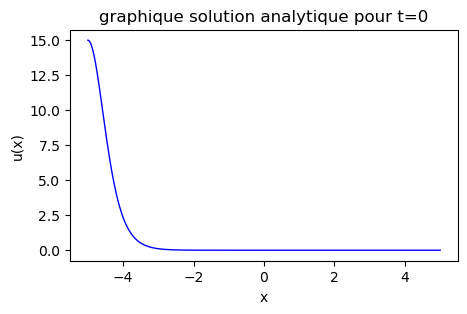

In [4]:
# ----------------------------------------
# Solution
# ----------------------------------------
# x : position 
# t : temps
def sol_an(x,t,x0):
    xi = x-c*t
    return 3*c/eps * sech(1/2 * math.sqrt(c/mu) * (xi-x0))**2

# ----------------------------------------
# Graphique pour la solution analytique
# ----------------------------------------
x = np.linspace(-5, 5, 1000)
u_t0 = sol_an(x, 0, x0)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, u_t0, color='blue', linewidth=1)
ax.set_xlabel("x")
ax.set_ylabel("u(x)")
ax.set_title("graphique solution analytique pour t=0")
plt.show()

# Mise en place du schéma de Crank-Nikolson

In [5]:
# ----------------------------------------
# Schéma de Crank-Nikolson avec résolution du système 
# ----------------------------------------
def sol_ck (x_debut,x_fin,Tf,Nx,Nt,eps,mu) :
    #x_debut : point de depart du maillage en x
    #x_fin : point de fin du maillage en x
    #Tf : temps de fin du maillage
    #Nx : nombre de subdivision en X
    #Nt : nombre de subdivision en temps

    t = 0 #temps de début

    #Pas du maillage
    hx = (x_fin - x_debut)/(Nx-1)
    ht = Tf/Nt
    
    #Constantes 
    alpha = (mu * ht) / (hx**3)
    beta = (eps * ht) / hx

    x = np.linspace(x_debut, x_fin, Nx)
    #Creation des matrices / vect
    Un = sol_an(x, 0, x0)
    matA = np.zeros ((Nx,Nx))
    MatB = np.zeros ((Nx,Nx))

    U_init = Un.copy()


    #Cond. de Dirichlet Un+1 = Un pour i = 0,1 & i = N-1,N
    matA[0,0] = matA[1,1] = 1 
    MatB[0,0] = MatB[1,1] = 1
    matA[Nx-2, Nx-2] = matA[Nx-1, Nx-1] = 1
    MatB[Nx-2, Nx-2] = MatB[Nx-1, Nx-1] = 1
     
    
    for i in range(Nt) : #a chaque temps
        gamma = (alpha / 2) - (beta / 4) * Un

        for j in range(2, Nx - 2):
            matA[j, j-2] = -alpha / 4
            matA[j, j-1] = gamma[j]
            matA[j, j]   = 1
            matA[j, j+1] = -gamma[j]
            matA[j, j+2] = alpha / 4
            
            MatB[j, j-2] = alpha / 4
            MatB[j, j-1] = -gamma[j]
            MatB[j, j]   = 1
            MatB[j, j+1] = gamma[j]
            MatB[j, j+2] = -alpha / 4
            
        # b = B * Un
        b = np.dot(MatB, Un)
        
        # Résolution A * Un+1 = b
        Un1 = np.linalg.solve(matA, b)
        Un = Un1.copy()

    return Un , x, U_init

In [6]:
# ----------------------------------------
# Schéma de Crank-Nikolson avec résolution du système pour une matrice sparse
# ----------------------------------------
def sol_ck_sparse (x_debut,x_fin,Tf,Nx,Nt,eps,mu) :
    #x_debut : point de depart du maillage en x
    #x_fin : point de fin du maillage en x
    #Tf : temps de fin du maillage
    #Nx : nombre de subdivision en X
    #Nt : nombre de subdivision en temps

    t = 0 #temps de début

    #Pas du maillage
    hx = (x_fin - x_debut)/(Nx-1)
    ht = Tf/Nt
    
    #Constantes 
    alpha = (mu * ht) / (hx**3)
    beta = (eps * ht) / hx

    x = np.linspace(x_debut, x_fin, Nx)
    #Creation des matrices / vect
    Un = sol_an(x, 0, x0)
    matA = np.zeros ((Nx,Nx))
    MatB = np.zeros ((Nx,Nx))

    U_init = Un.copy()


    #Cond. de Dirichlet Un+1 = Un pour i = 0,1 & i = N-1,N
    matA[0,0] = matA[1,1] = 1 
    MatB[0,0] = MatB[1,1] = 1
    matA[Nx-2, Nx-2] = matA[Nx-1, Nx-1] = 1
    MatB[Nx-2, Nx-2] = MatB[Nx-1, Nx-1] = 1
     
    
    for i in range(Nt) : # a chaque temps
        gamma = (alpha / 2) - (beta / 4) * Un

        for j in range(2, Nx - 2):
            matA[j, j-2] = -alpha / 4
            matA[j, j-1] = gamma[j]
            matA[j, j]   = 1
            matA[j, j+1] = -gamma[j]
            matA[j, j+2] = alpha / 4
            
            MatB[j, j-2] = alpha / 4
            MatB[j, j-1] = -gamma[j]
            MatB[j, j]   = 1
            MatB[j, j+1] = gamma[j]
            MatB[j, j+2] = -alpha / 4

        # Stockage sparse de A
        matA_sp = csr_matrix(matA)
        
        # b = B * Un
        b = np.dot(MatB, Un) # Moins performant de passer MatB en sparse
        
        # Résolution A * Un+1 = b
        Un1 = spsolve(matA_sp, b)
        Un = Un1.copy()

    return Un , x, U_init

# Calcul des solutions & mesure des temps de Calcul

In [7]:
# Paramètres du domaine optimisés pour éviter les oscillations
x_debut = -15
x_fin = 15
Tf = 10
Nx = 600   # Assez fin pour la précision, assez petit pour np.linalg.solve
Nt = 1000

In [8]:
# Matrice pleine
start_sol_ck = time.perf_counter()
U_numerique_final, x_num, U_initial = sol_ck(x_debut, x_fin, Tf, Nx, Nt, eps, mu)
end_sol_ck = time.perf_counter()

In [9]:
# Matrice sparse
start_sol_ck_sp = time.perf_counter()
U_numerique_final_sp, x_num_sp, U_initial_sp = sol_ck_sparse(x_debut, x_fin, Tf, Nx, Nt, eps, mu)
end_sol_ck_sp = time.perf_counter()

In [10]:
# Calcul de la théorie exacte au temps final pour comparaison
start_sol_an = time.perf_counter()
U_analytique_final = sol_an(x_num, Tf, x0)
end_sol_an = time.perf_counter()

In [11]:
# Temps de calculs
print(f"Temps d'exécution solution numérique Matrice pleine : {end_sol_ck - start_sol_ck} secondes")
print(f"Temps d'exécution solution numérique Matrice sparse : {end_sol_ck_sp - start_sol_ck_sp} secondes")
print(f"Temps d'exécution solution analitique : {start_sol_an - start_sol_an} secondes")

Temps d'exécution solution numérique Matrice pleine : 4.670542972000007 secondes
Temps d'exécution solution numérique Matrice sparse : 1.9726714170000008 secondes
Temps d'exécution solution analitique : 0.0 secondes


# Comparaison des résultats numérique et de la solution analytique (Q2)

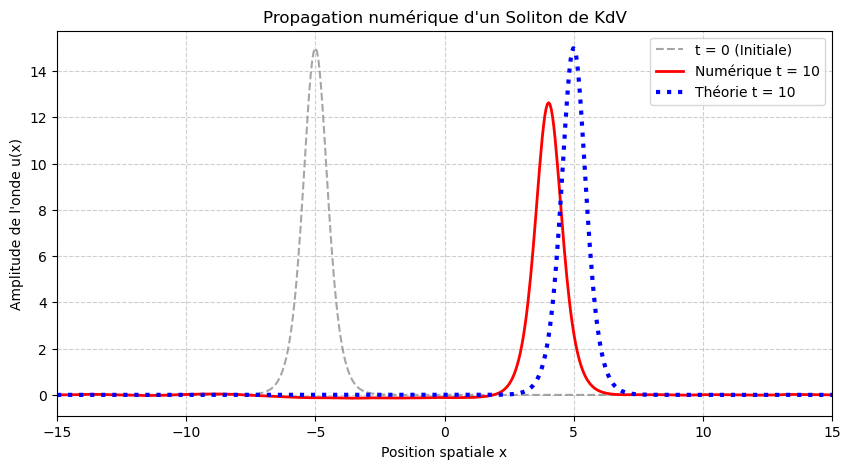

In [12]:
# ----------------------------------------
# Graphique Crank-Nikolson -----------GENERE PAR IA--------------
# ----------------------------------------

# Création du graphique esthétique et clair
plt.figure(figsize=(10, 5))

# 1. Courbe de l'état initial (pour prouver que l'onde s'est déplacée)
plt.plot(x_num, U_initial, '--', color='gray', alpha=0.7, label='t = 0 (Initiale)')

# 2. Courbe de ta solution numérique -Version full- (le résultat de ton schéma Crank-Nicolson) 
plt.plot(x_num_sp, U_numerique_final_sp, label=f'Numérique t = {Tf}', color='red', linewidth=2)

# 3. Courbe de la solution analytique exacte (pour valider le calcul)
plt.plot(x_num, U_analytique_final, ':', color='blue', linewidth=3, label=f'Théorie t = {Tf}')

# Finitions du graphique
plt.xlabel("Position spatiale x")
plt.ylabel("Amplitude de l'onde u(x)")
plt.title("Propagation numérique d'un Soliton de KdV")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(x_debut, x_fin)
plt.show()

# Animation

In [20]:
# Temps
temps = np.linspace(0, 1000, Nt)
x = np.linspace(x_debut, x_fin, Nx)

U_num_total = np.zeros((len(temps),len(x)))
U_num_total[0] = sol_an(x, 0, x0)

for t in range(1, len(temps)):
    U_numerique_final_sp, _, _ = sol_ck_sparse(x_debut, x_fin, i, Nx, t, eps, mu)
    U_num_total[t, :] = U_numerique_final_sp

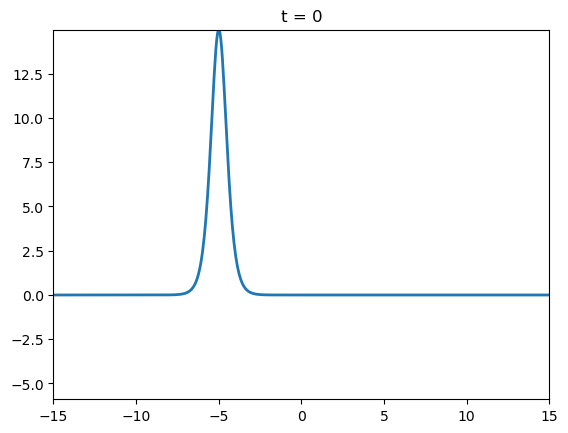

In [21]:

# Figure
fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)

# Limites
ax.set_xlim(-15, 15)
ax.set_ylim(U_num_total.min(), U_num_total.max())

# Fonction d'animation
def update(i):
    line.set_data(x, U_num_total[i, :])
    ax.set_title(f"t = {i}")
    return line

# Animation
ani = FuncAnimation(fig, update, frames=len(temps),interval=30)

HTML(ani.to_html5_video())